In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("./water_quality_processed.csv")

In [3]:
df.head()

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,W254029084355301,Himachal Pradesh,Solan,nallagarh,jagatpur,31.159400,76.678500,2019,8.44,5.703782,...,1.308333,4.442651,2.890372,2.397895,3.688879,1.223775,0.182322,5.572154,85.80466,Good
1,W193530074180001,Maharashtra,Ahmednagar,sangamner,kokangaon,74.300000,19.591667,2022,7.90,7.182352,...,2.954910,6.144186,4.396915,4.180522,4.492001,0.955511,0.425268,5.921578,280.04130,Very Poor yet Drinkable
2,W251908084361501,Himachal Pradesh,Solan,nallagarh,baruna,31.154000,76.638400,2019,8.40,5.602119,...,2.397895,4.762174,2.397895,2.944439,3.178054,0.693147,0.113329,5.572154,81.77860,Good
3,W192600074540001,Maharashtra,Ahmednagar,nevasa,vadala bhairoba,74.900000,19.433333,2022,7.55,7.322510,...,4.169761,6.236370,4.763882,3.998201,4.578826,2.104134,0.165514,6.710523,376.42330,Unsuitable for Drinking
4,W222230071591001,Gujarat,Ahmedabad,dhandhuka,dhandhuka1,22.376073,71.987684,2020,8.20,8.899594,...,5.398163,6.525030,4.290459,4.812184,7.233455,3.806662,1.360977,8.499233,1944.80480,Unsuitable for Drinking


In [4]:
df.columns

Index(['Well_ID', 'State', 'District', 'Block', 'Village', 'Latitude',
       'Longitude', 'Year', 'pH', 'EC', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca',
       'Mg', 'Na', 'K', 'F', 'TDS', 'WQI', 'Water Quality Classification'],
      dtype='str')

In [5]:
df.drop(['Well_ID', 'State', 'District', 'Block', 'Village'], axis=1, inplace=True) # dropping redundant features, as we already have lat/lon
df.drop(["WQI"], axis=1, inplace=True) # not useful for predicting WQI

In [8]:
le = LabelEncoder()
df["Encoded_Target"] = le.fit_transform(df["Water Quality Classification"])

In [9]:
df.drop(["Water Quality Classification"], axis=1, inplace=True)

In [10]:
corr = df.corr()

In [11]:
corr

,Latitude,Longitude,Year,pH,EC,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,Encoded_Target
Latitude,1.000000,-0.005465,0.854333,0.005633,0.013385,0.120909,-0.020529,-0.040547,-0.116188,0.027744,-0.008622,0.038620,-0.008933,0.083760,0.003785,0.045802,0.124058
Longitude,-0.005465,1.000000,0.002931,0.005896,-0.002842,-0.000751,-0.001539,0.002484,-0.001969,-0.002127,-0.001988,-0.000760,0.000179,-0.002328,0.003952,-0.002715,-0.005939
Year,0.854333,0.002931,1.000000,-0.009257,0.020016,0.097579,0.016778,-0.012043,-0.058907,0.039514,0.015493,0.037994,0.023424,0.069465,0.005186,0.073820,0.123299
pH,0.005633,0.005896,-0.009257,1.000000,0.116622,0.187580,0.034712,0.101086,-0.107069,0.055778,-0.030725,0.104279,0.149672,0.100404,0.140730,0.034082,0.094539
EC,0.013385,-0.002842,0.020016,0.116622,1.000000,0.751662,0.863985,0.703633,0.495022,0.881334,0.725067,0.799129,0.861438,0.347052,0.407646,0.700873,0.608919
HCO3,0.120909,-0.000751,0.097579,0.187580,0.751662,1.000000,0.480623,0.410187,0.258314,0.751849,0.620593,0.669503,0.610838,0.210357,0.365998,0.515978,0.587860
Cl,-0.020529,-0.001539,0.016778,0.034712,0.863985,0.480623,1.000000,0.647547,0.466388,0.744540,0.602385,0.688360,0.816248,0.372332,0.329064,0.627156,0.467463
SO4,-0.040547,0.002484,-0.012043,0.101086,0.703633,0.410187,0.647547,1.000000,0.434739,0.606653,0.468934,0.582897,0.651095,0.303231,0.390247,0.504815,0.396101
NO3,-0.116188,-0.001969,-0.058907,-0.107069,0.495022,0.258314,0.466388,0.434739,1.000000,0.468423,0.434285,0.386219,0.404335,0.130543,0.209802,0.372640,0.342475
TH,0.027744,-0.002127,0.039514,0.055778,0.881334,0.751849,0.744540,0.606653,0.468423,1.000000,0.847912,0.874839,0.625918,0.233358,0.312408,0.625983,0.582835


Saved → correlation_heatmap.png


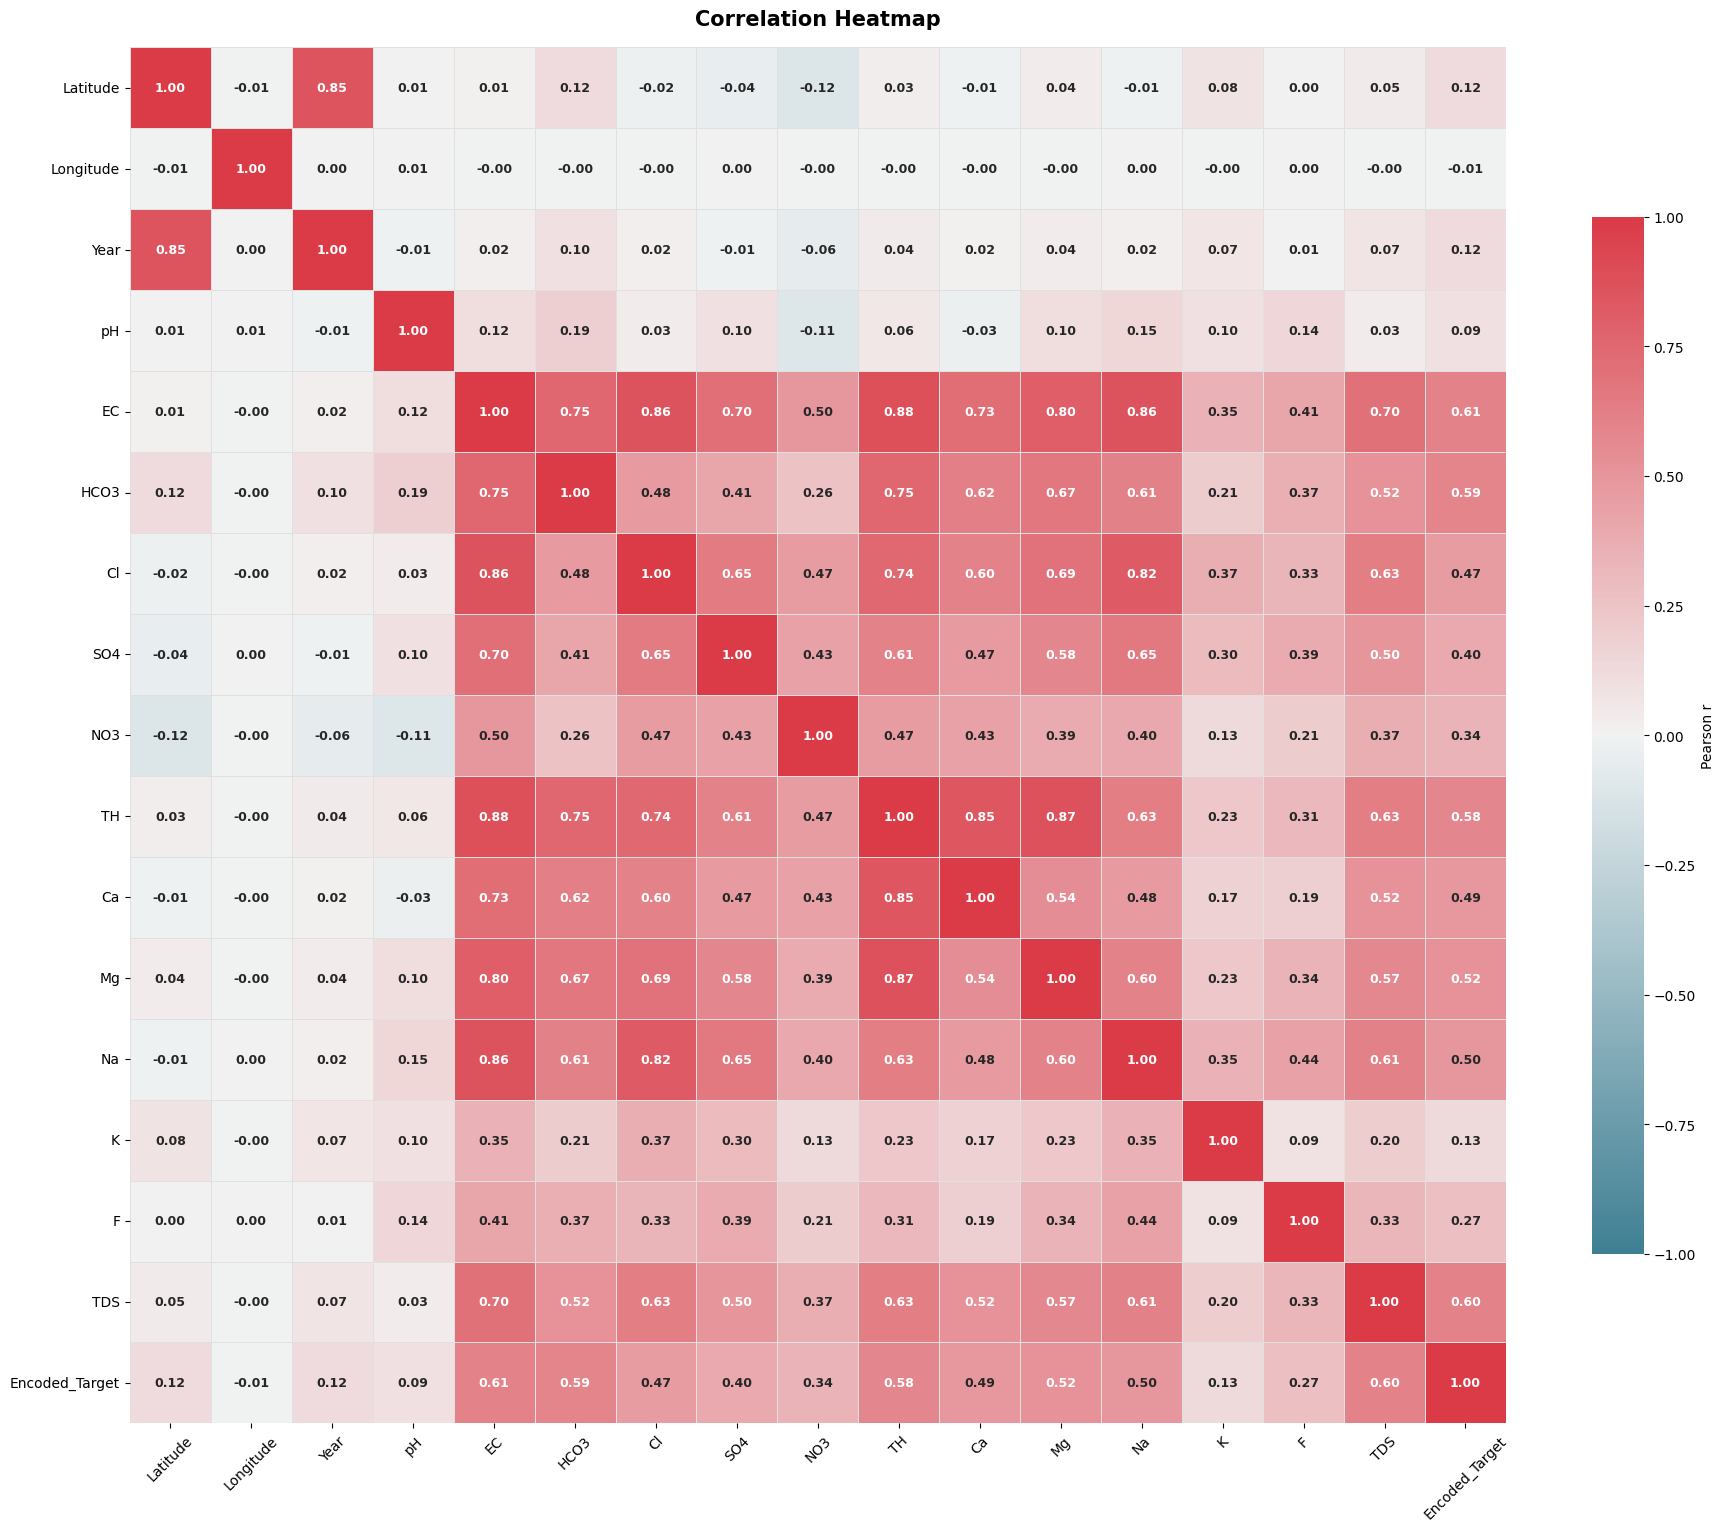

In [12]:
n = len(corr)
fig, ax = plt.subplots(figsize=(max(8, n * 1.1), max(6, n * 0.9)))
 
# Diverging palette: blue (negative) → white → red (positive)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
 
mask = np.zeros_like(corr, dtype=bool)          # show full matrix
# Uncomment next line to hide the upper triangle:
# mask[np.triu_indices_from(mask)] = True
 
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    annot_kws={"size": 9, "weight": "bold"},
    linewidths=0.5, linecolor="#e0e0e0",
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    ax=ax,
)
 
# Titles & labels
ax.set_title("Correlation Heatmap", fontsize=15, fontweight="bold", pad=16)
ax.tick_params(axis="x", labelrotation=45, labelsize=10)
ax.tick_params(axis="y", labelrotation=0,  labelsize=10)
 
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved → correlation_heatmap.png")
plt.show()

In [13]:
df.columns

Index(['Latitude', 'Longitude', 'Year', 'pH', 'EC', 'HCO3', 'Cl', 'SO4', 'NO3',
       'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'Encoded_Target'],
      dtype='str')

In [14]:
# we are dropping features, because of the multicollinearity
features = ['Latitude', 'Longitude', 'Year', 'pH', 'EC', 'Cl', 'Na', 'HCO3', 'SO4', 'NO3', 'K', 'F']
target ="WQI"

In [16]:
X = df[features]
y = df['Encoded_Target']

print(X.shape)
print(y.shape)

(14493, 12)
(14493,)


In [17]:
X.describe()

,Latitude,Longitude,Year,pH,EC,Cl,Na,HCO3,SO4,NO3,K,F
count,14493.000000,1.449300e+04,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000,14493.000000
mean,42.233266,5.144861e+03,2020.533016,7.709810,6.728953,4.387403,4.103654,5.469345,3.390232,2.814516,1.744239,0.408233
std,29.117081,6.125580e+05,1.305614,0.479403,0.842433,1.151295,1.079858,0.809371,1.316601,1.389103,1.105034,0.281685
min,0.000000,0.000000e+00,2019.000000,3.060000,1.190888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.174353
25%,21.185556,2.305344e+01,2019.000000,7.450000,6.318608,3.583519,3.427515,5.214936,2.708050,1.840550,0.955511,0.190620
50%,24.362000,7.496900e+01,2021.000000,7.700000,6.778785,4.369448,4.127134,5.648974,3.465736,3.034953,1.458615,0.364643
75%,77.013611,7.846670e+01,2022.000000,7.990000,7.226936,5.141664,4.779123,5.969986,4.219508,3.804438,2.312535,0.576613
max,95.899167,7.374400e+07,2022.000000,10.610000,10.185692,9.128913,8.610684,8.043342,8.000014,7.336872,7.210818,1.360977


In [18]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [20]:
print(x_train.shape, x_test.shape)

(11594, 12) (2899, 12)


In [21]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

In [ ]:
y_train_tensor = torch.tensor(y_train, dtype=torch.long).squeeze()
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long).squeeze()

In [35]:
class WaterQualityModel(nn.Module):
    def __init__(self, input_dim, num_classes=5):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, 128)
        self.layer2 = nn.Linear(128, 32)
        self.layer3 = nn.Linear(32, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)  # logits
        return x

In [36]:
model = WaterQualityModel(12, 5)
model

WaterQualityModel(
  (layer1): Linear(in_features=12, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=5, bias=True)
  (relu): ReLU()
)

In [37]:
print(torch.unique(y_train_tensor))

tensor([0, 1, 2, 3, 4])


In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 1000

for epoch in range(epochs):
    model.train()

    # 1. forward pass
    predictions = model(x_train_tensor)
    # 2. compute loss
    loss = criterion(predictions, y_train_tensor)
    # 3. zero gradients
    optimizer.zero_grad()
    # 4. backward pass
    loss.backward()
    # 5. update weights
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_preds = model(x_test_tensor)
        test_loss  = criterion(test_preds, y_test_tensor)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

Epoch 0 | Train Loss: 1.6434 | Test Loss: 1.6250
Epoch 100 | Train Loss: 0.5613 | Test Loss: 0.5596
Epoch 200 | Train Loss: 0.4325 | Test Loss: 0.4368
Epoch 300 | Train Loss: 0.3703 | Test Loss: 0.3809
Epoch 400 | Train Loss: 0.3376 | Test Loss: 0.3572
Epoch 500 | Train Loss: 0.3152 | Test Loss: 0.3443
Epoch 600 | Train Loss: 0.2963 | Test Loss: 0.3350
Epoch 700 | Train Loss: 0.2808 | Test Loss: 0.3282
Epoch 800 | Train Loss: 0.2667 | Test Loss: 0.3246
Epoch 900 | Train Loss: 0.2537 | Test Loss: 0.3232


In [45]:
model.eval()

with torch.inference_mode():
    logits = model(x_test_tensor)
    preds = torch.argmax(logits, dim=1)

accuracy = (preds == y_test_tensor).float().mean()
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8751


In [50]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_tensor.cpu(), preds.cpu()))
print(confusion_matrix(y_test_tensor.cpu(), preds.cpu()))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        92
           1       0.83      0.81      0.82       214
           2       0.88      0.88      0.88       784
           3       0.95      0.91      0.93      1067
           4       0.79      0.85      0.82       742

    accuracy                           0.88      2899
   macro avg       0.86      0.86      0.86      2899
weighted avg       0.88      0.88      0.88      2899

[[ 78  12   2   0   0]
 [ 11 173  27   0   3]
 [  1  20 687   2  74]
 [  0   0   7 970  90]
 [  0   3  61  49 629]]
